In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from gammatone.filters import make_erb_filters, erb_filterbank, centre_freqs
from brian2 import *

In [2]:
# ==============================
# Step 1. Load audio
# ==============================
audio_path = "datasets/vox1_small/id10019/id10019_00004/00001.wav"

signal, sr = librosa.load(audio_path, sr=16000)

print("Sampling rate:", sr)
print("Signal shape:", signal.shape) 

print("Min value:", np.min(signal))
print("Max value:", np.max(signal))

WARNING    /home/qphulong/workspace/snn_playground/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 [py.warnings]


Sampling rate: 16000
Signal shape: (80000,)
Min value: -0.97891235
Max value: 0.9581299


Spectrogram shape: (513, 313)
Min value: 1.1836848e-05
Max value: 124.333565


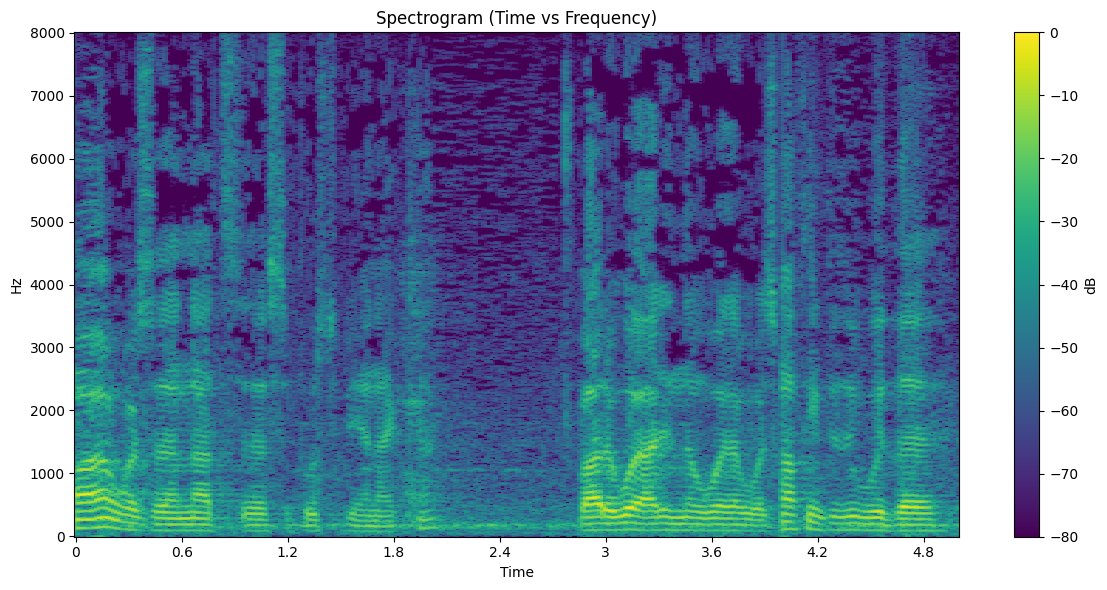

In [3]:
# ==============================
# VISUALIZATION Spectrogram (Time vs Frequency)
# ==============================

# Compute STFT
stft = librosa.stft(signal, n_fft=1024, hop_length=256)

# Convert to magnitude
spectrogram = np.abs(stft)

print("Spectrogram shape:", spectrogram.shape)
print("Min value:", spectrogram.min())
print("Max value:", spectrogram.max())

# Convert amplitude to dB for better visualization
spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

# Plot
plt.figure(figsize=(12, 6))
librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    hop_length=256,
    x_axis="time",
    y_axis="hz",
    cmap="viridis"
)
plt.title("Spectrogram (Time vs Frequency)")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

In [4]:
# ==============================
# Step 2. Create ERB-spaced filters
# ==============================
num_filters = 100
f_min = 50

# Original order (HIGH → LOW)
cf = centre_freqs(sr, num_filters, f_min)

# Create filters
erb_filters = make_erb_filters(sr, cf)

# Apply filterbank
filtered_signals = erb_filterbank(signal, erb_filters)

# ==============================
# Step 3. Reorder to LOW → HIGH
# ==============================
cf = cf[::-1]
filtered_signals = filtered_signals[::-1] # OUTPUT of gammatone

Filtered signals shape: (100, 80000)
Number of filters: 100
Samples per filter: 80000
Global min value: -0.5981654197888546
Global max value: 0.597127729999433
Filter 30 center frequency: 540.90 Hz
Filter 35 center frequency: 682.85 Hz
Filter 40 center frequency: 850.96 Hz
Filter 45 center frequency: 1050.08 Hz


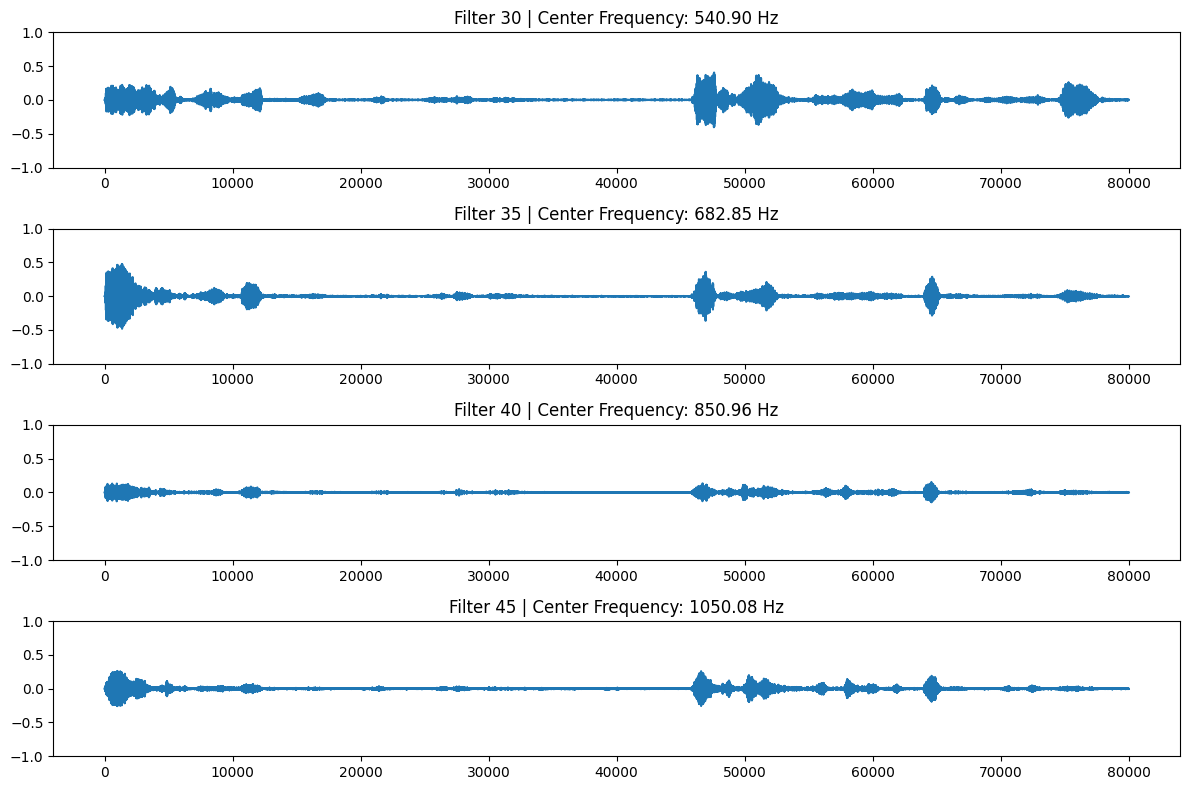

In [5]:
# ==============================
# VISUALIZATION filtered signals
# ==============================

print("Filtered signals shape:", filtered_signals.shape)
print("Number of filters:", filtered_signals.shape[0])
print("Samples per filter:", filtered_signals.shape[1])
print("Global min value:", np.min(filtered_signals))
print("Global max value:", np.max(filtered_signals))

filters = [30,35,40,45]  # indices to visualize
selected = filtered_signals[filters]

plt.figure(figsize=(12, len(filters) * 2))

for i, idx in enumerate(filters):
    center_frequency = cf[idx]  # center frequency of this filter

    print(f"Filter {idx} center frequency: {center_frequency:.2f} Hz")

    plt.subplot(len(filters), 1, i + 1)
    plt.plot(filtered_signals[idx])
    plt.ylim(-1, 1)  # fixed scale
    plt.title(f"Filter {idx} | Center Frequency: {center_frequency:.2f} Hz")

plt.tight_layout()
plt.show()

E shape: (100, 80000)
E min: 0.0 | E max: 0.4682068472489712


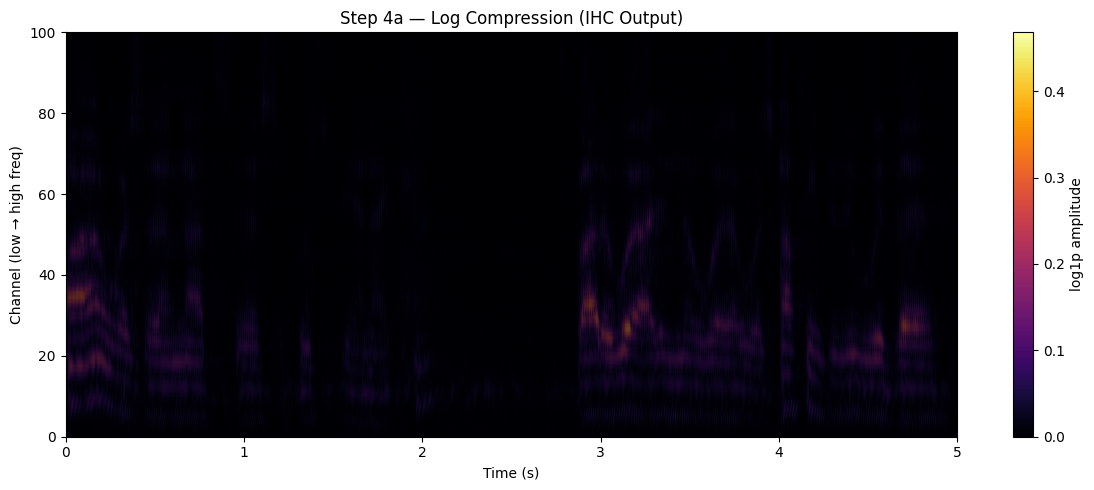

In [6]:
# ==============================
# Step 4a. Log Compression (IHC)
# ==============================
signals = filtered_signals
n_channels, T = signals.shape

alpha = 1.0
E = np.log1p(alpha * np.maximum(signals, 0))

print("E shape:", E.shape)
print("E min:", E.min(), "| E max:", E.max())

plt.figure(figsize=(12, 5))
plt.imshow(E, aspect='auto', origin='lower', cmap='inferno',
           extent=[0, T / sr, 0, n_channels])
plt.title("Step 4a — Log Compression (IHC Output)")
plt.xlabel("Time (s)")
plt.ylabel("Channel (low → high freq)")
plt.colorbar(label="log1p amplitude")
plt.tight_layout()
plt.show()

dE shape: (100, 80000)
dE min: 0.0 | dE max: 0.9999924721000797


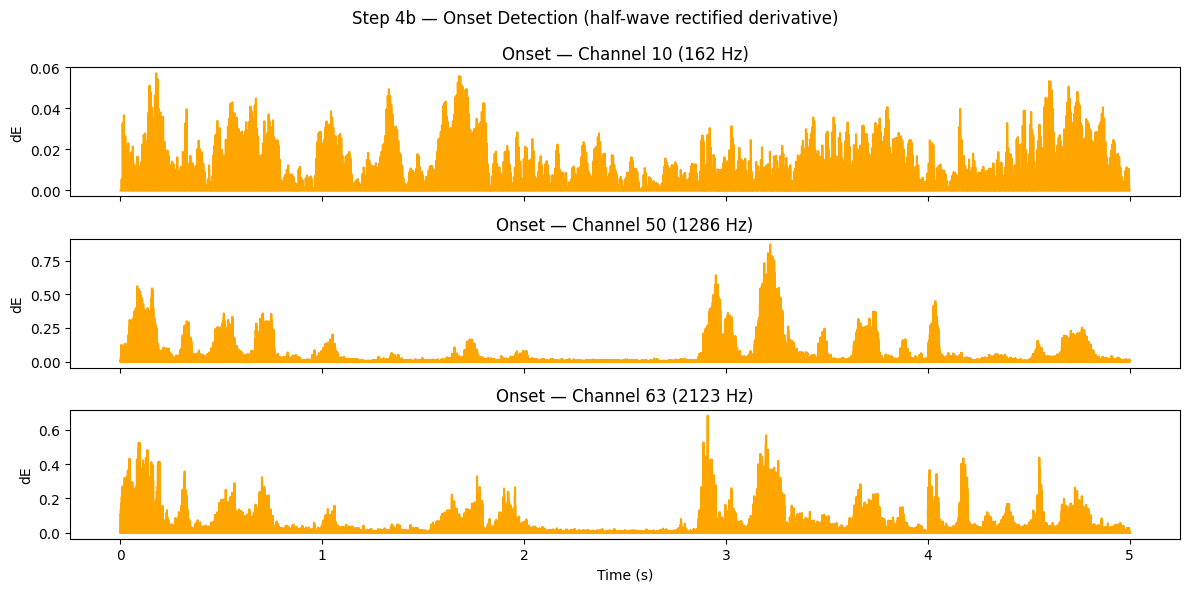

In [7]:
# ==============================
# Step 4b. Onset Detection
# ==============================
dE = np.diff(E, axis=1, prepend=E[:, :1])
dE[dE < 0] = 0

# Normalize to [0, 1]
dE_max = np.max(dE) + 1e-6
dE = dE / dE_max

print("dE shape:", dE.shape)
print("dE min:", dE.min(), "| dE max:", dE.max())

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, ch in enumerate([10, 50, 63]):
    axes[i].plot(np.arange(T) / sr, dE[ch], color='orange')
    axes[i].set_title(f"Onset — Channel {ch} ({cf[ch]:.0f} Hz)")
    axes[i].set_ylabel("dE")
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Step 4b — Onset Detection (half-wave rectified derivative)")
plt.tight_layout()
plt.show()

Phase signal shape: (100, 80000)


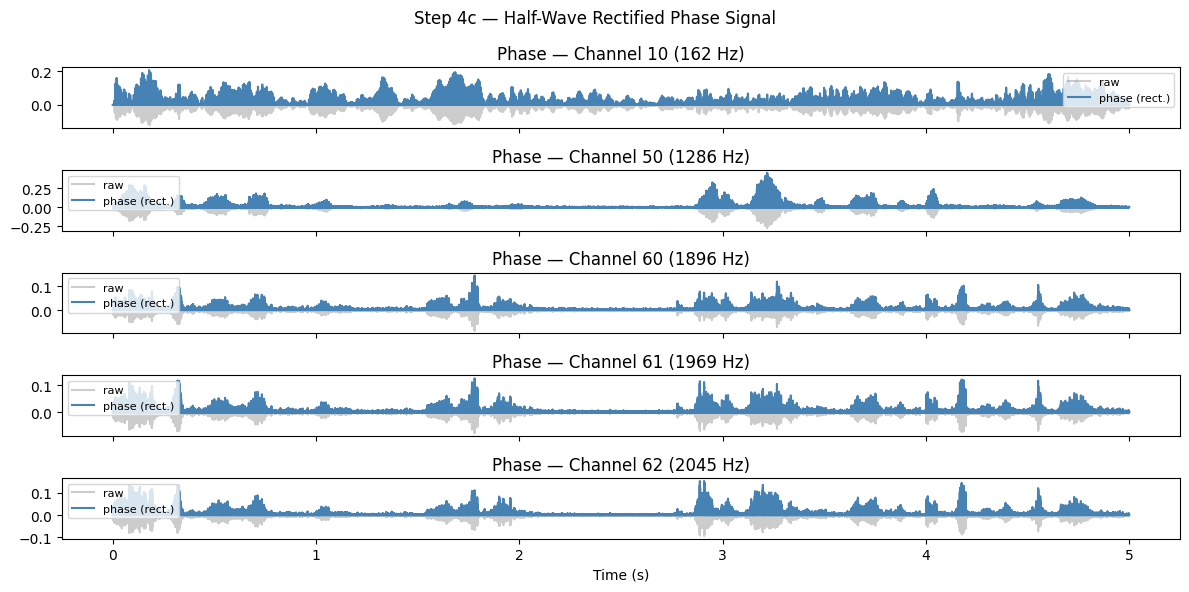

In [8]:
# ==============================
# Step 4c. Phase Signal (Half-Wave Rectification)
# ==============================
phase_signal = np.maximum(signals, 0)

# Normalize to [0, 1]
phase_max = np.max(phase_signal) + 1e-6
phase_signal = phase_signal / phase_max

print("Phase signal shape:", phase_signal.shape)

fig, axes = plt.subplots(5, 1, figsize=(12, 6), sharex=True)
for i, ch in enumerate([10, 50, 60,61,62]):
    t = np.arange(T) / sr
    axes[i].plot(t, signals[ch], alpha=0.4, label='raw', color='gray')
    axes[i].plot(t, phase_signal[ch], label='phase (rect.)', color='steelblue')
    axes[i].set_title(f"Phase — Channel {ch} ({cf[ch]:.0f} Hz)")
    axes[i].legend(fontsize=8)
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Step 4c — Half-Wave Rectified Phase Signal")
plt.tight_layout()
plt.show()

E_norm min: 0.0 | E_norm max: 0.9999978641964122


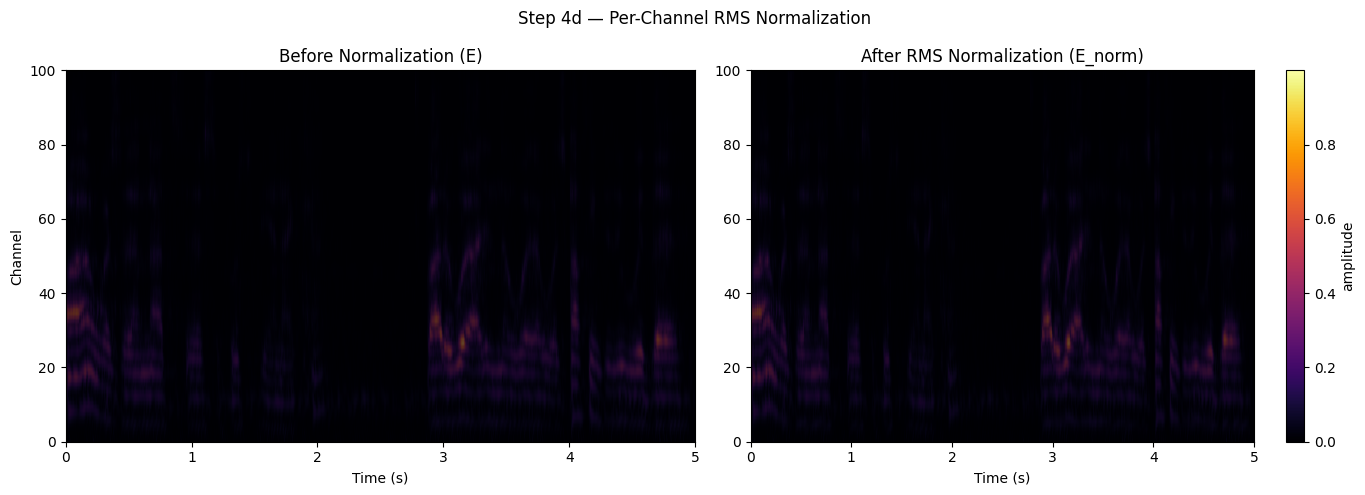

In [9]:
# ==============================
# Step 4d. Per-Channel RMS Normalization
# ==============================
# rms = np.sqrt(np.mean(E**2, axis=1, keepdims=True)) + 1e-6 
# E_norm = E / rms

E_global_max = np.max(np.abs(E)) + 1e-6
E_norm = E / E_global_max

print("E_norm min:", E_norm.min(), "| E_norm max:", E_norm.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(E, aspect='auto', origin='lower', cmap='inferno',
               extent=[0, T / sr, 0, n_channels])
axes[0].set_title("Before Normalization (E)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Channel")
im = axes[1].imshow(E_norm, aspect='auto', origin='lower', cmap='inferno',
                    extent=[0, T / sr, 0, n_channels])
axes[1].set_title("After RMS Normalization (E_norm)")
axes[1].set_xlabel("Time (s)")
fig.colorbar(im, ax=axes[1], label="amplitude")
plt.suptitle("Step 4d — Per-Channel RMS Normalization")
plt.tight_layout()
plt.show()

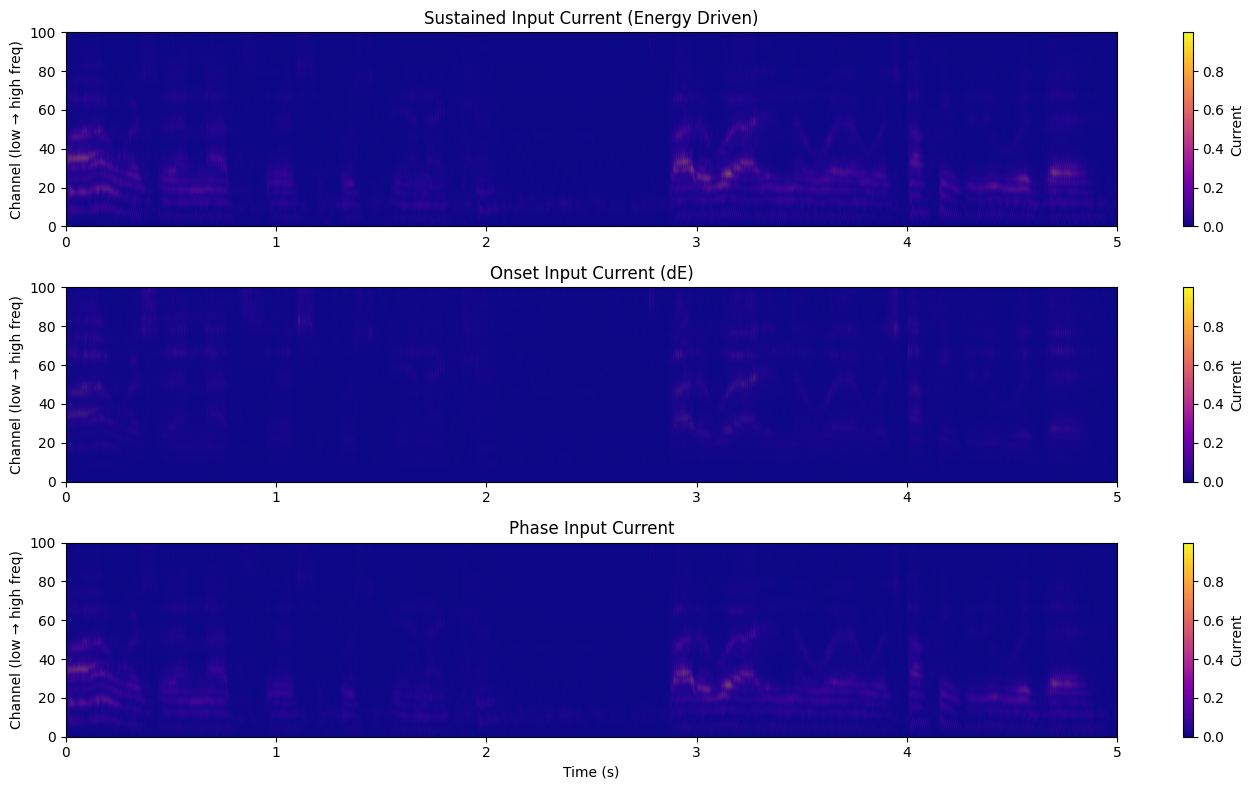

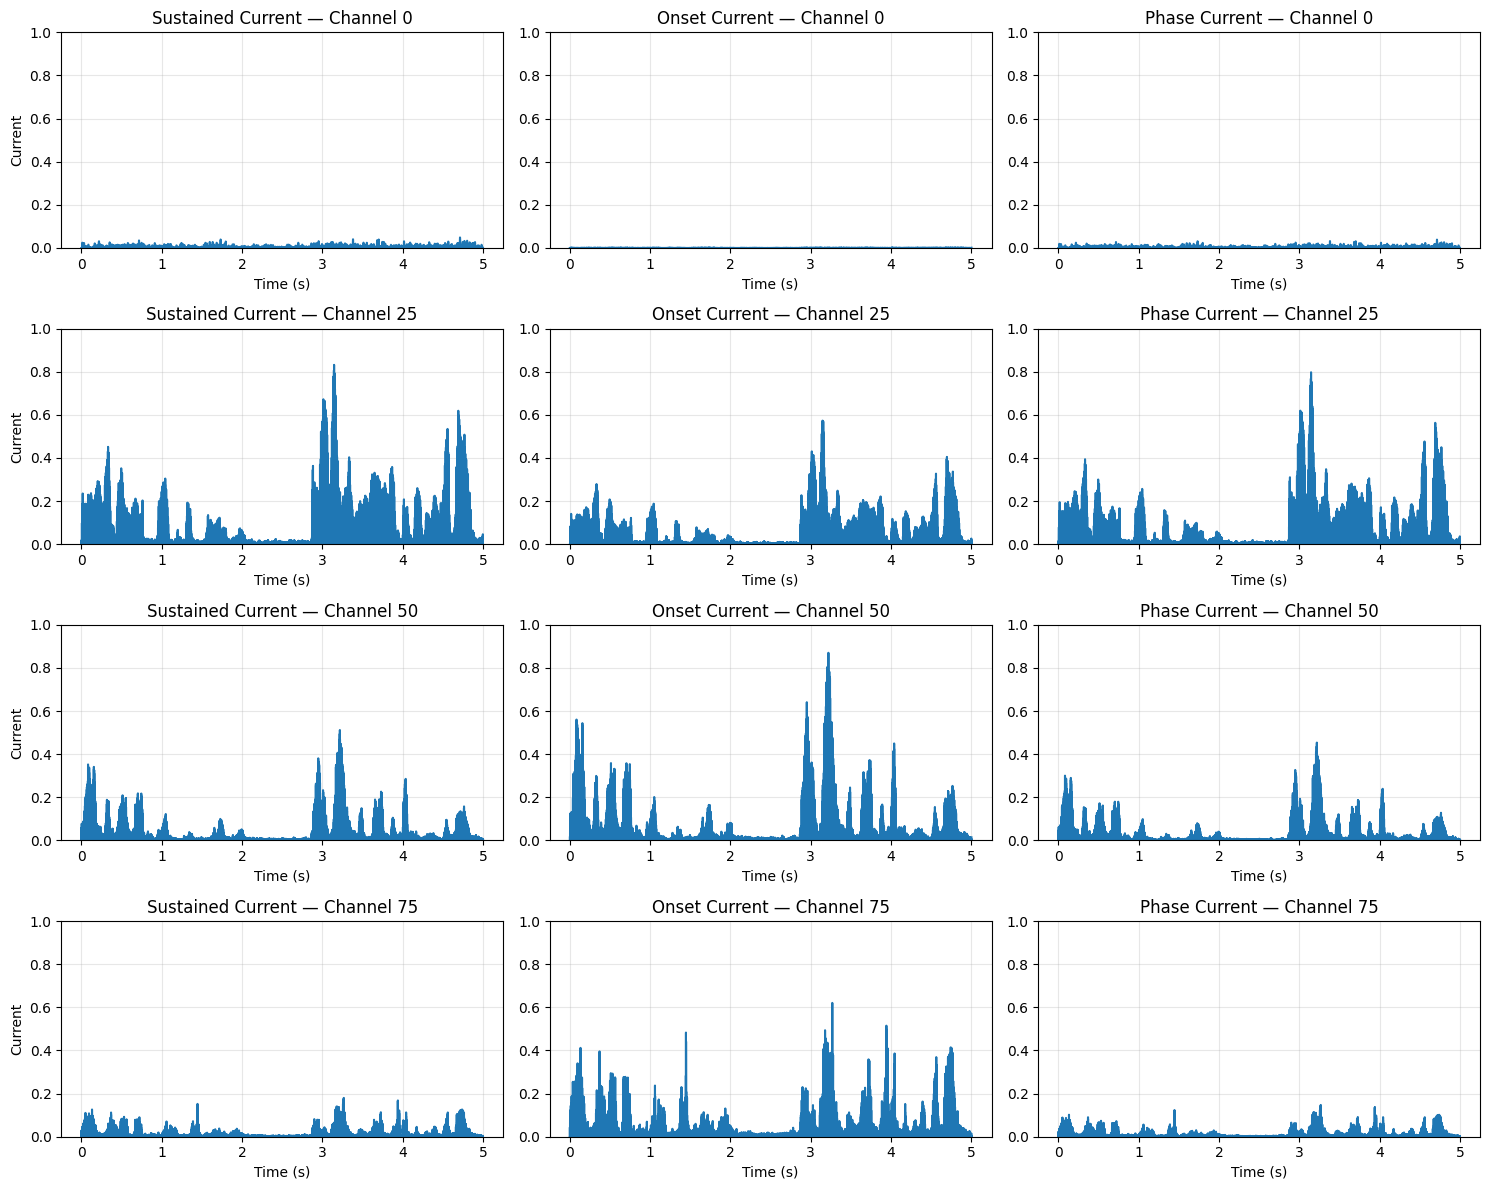

In [10]:
# ==============================
# Step X. Visualize Input Currents
# ==============================

# Channels to inspect individually
ch_vis = np.array([0, n_channels//4, n_channels//2, 3*n_channels//4])

# Time axis
t_axis = np.arange(T) / sr

I_sust = E_norm
I_onset = dE
I_phase = phase_signal


# ==============================
# 1. Heatmap Overview (All Channels)
# ==============================

plt.figure(figsize=(14,8))

plt.subplot(3,1,1)
plt.imshow(I_sust, aspect='auto', origin='lower',
           extent=[0, T/sr, 0, n_channels],
           cmap='plasma')
plt.title("Sustained Input Current (Energy Driven)")
plt.ylabel("Channel (low → high freq)")
plt.colorbar(label="Current")

plt.subplot(3,1,2)
plt.imshow(I_onset, aspect='auto', origin='lower',
           extent=[0, T/sr, 0, n_channels],
           cmap='plasma')
plt.title("Onset Input Current (dE)")
plt.ylabel("Channel (low → high freq)")
plt.colorbar(label="Current")

plt.subplot(3,1,3)
plt.imshow(I_phase, aspect='auto', origin='lower',
           extent=[0, T/sr, 0, n_channels],
           cmap='plasma')
plt.title("Phase Input Current")
plt.xlabel("Time (s)")
plt.ylabel("Channel (low → high freq)")
plt.colorbar(label="Current")

plt.tight_layout()
plt.show()


# ==============================
# 2. Detailed View (Selected Channels)
# ==============================

fig, axes = plt.subplots(len(ch_vis), 3, figsize=(15, 3*len(ch_vis)))

for i, ch in enumerate(ch_vis):

    axes[i,0].plot(t_axis, I_sust[ch])
    axes[i,0].set_title(f"Sustained Current — Channel {ch}")
    axes[i,0].set_ylabel("Current")
    axes[i,0].set_ylim(0, 1)

    axes[i,1].plot(t_axis, I_onset[ch])
    axes[i,1].set_title(f"Onset Current — Channel {ch}")
    axes[i,1].set_ylim(0, 1)

    axes[i,2].plot(t_axis, I_phase[ch])
    axes[i,2].set_title(f"Phase Current — Channel {ch}")
    axes[i,2].set_ylim(0, 1)

    for j in range(3):
        axes[i,j].set_xlabel("Time (s)")
        axes[i,j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

WARNING    'i' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 3. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    't' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value array([0.0000000e+00, 6.2500000e-05, 1.2500000e-04, ..., 4.9998125e+00,
       4.9998750e+00, 4.9999375e+00], shape=(80000,)). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Total spikes: 24625


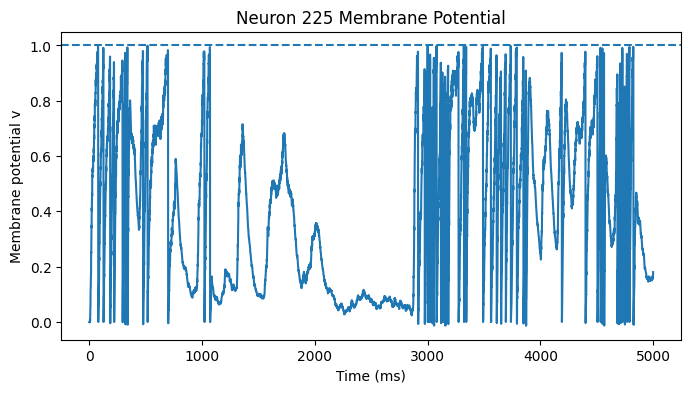

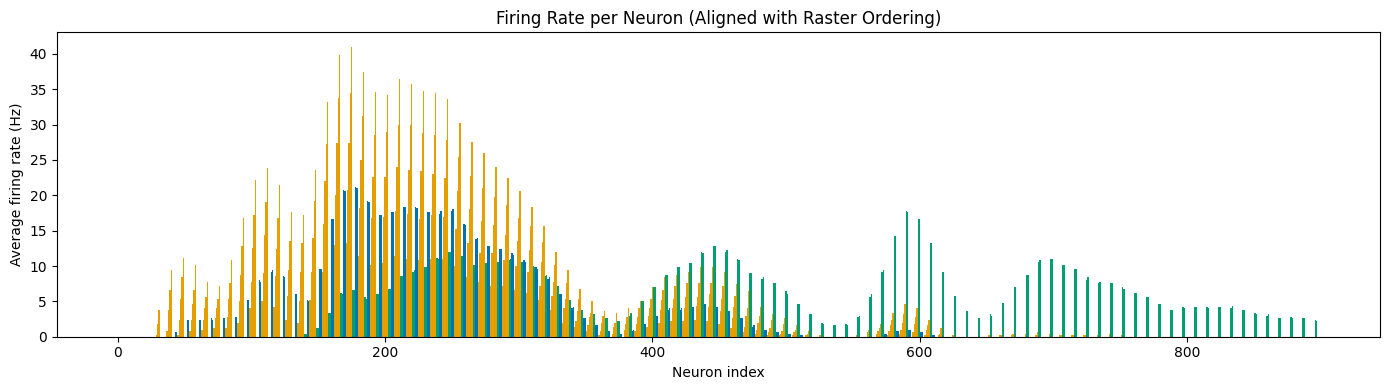

In [ ]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Step 5. Spike Encoding (Brian2 Adaptive LIF)
# ==============================
start_scope()

dt_sim = 1 * ms
defaultclock.dt = dt_sim

# Neuron population layout
sustained_per_band = 5
onset_per_band = 2
phase_per_band = 2
neurons_per_band = sustained_per_band + onset_per_band + phase_per_band
N = n_channels * neurons_per_band

# ==============================
# Build input current matrix
# ==============================
SCALE = 1

# Direct gains
g_sust  = 1
g_onset = 2
g_phase = 1

sust_spread_min = 0.6
sust_spread_max = 1.4

I = np.zeros((N, T))
idx = 0

for ch in range(n_channels):

    spread = np.linspace(sust_spread_min, sust_spread_max, sustained_per_band)

    for mult in spread:
        I[idx] = g_sust * mult * SCALE * E_norm[ch]
        idx += 1

    for _ in range(onset_per_band):
        I[idx] = g_onset * SCALE * dE[ch]
        idx += 1

    for _ in range(phase_per_band):
        I[idx] = g_phase * SCALE * phase_signal[ch]
        idx += 1

# small noise
I += 0.01 * np.random.randn(*I.shape)

# ==============================
# Downsample input ([,80000] -> [,5000]) reduce by 16 due to sampling rate
# ==============================

fs = 16000
target_fs = 1000
factor = fs // target_fs   # 16

I_ds = I.reshape(N, -1, factor).mean(axis=2)

T_ds = I_ds.shape[1]

# ==============================
# Convert to TimedArray
# ==============================

I_timed = TimedArray(I_ds.T, dt=dt_sim)

# ==============================
# Adaptive LIF model
# ==============================

tau_m = 40 * ms
tau_a = 20 * ms
beta  = 0.25
tau_current = 1 * ms # not really a tau, just to satisfy the unit convension for brian2

eqs = """
dv/dt = (-v - a) / tau_m + I_timed(t,i) / tau_current : 1
da/dt = -a / tau_a : 1
"""

G = NeuronGroup(
    N,
    eqs,
    threshold='v > 1',
    reset='v = 0; a += beta',
    refractory=2 * ms,
    method='euler'
)

G.v = 0
G.a = 0

# ==============================
# Monitoring
# ==============================

# neurons_to_inspect = [225, 226, 227, 228, 229,230,231,232,233]
neurons_to_inspect = [225]
state_mon = StateMonitor(G, 'v', record=neurons_to_inspect)
spikes = SpikeMonitor(G)

# ==============================
# Run simulation
# ==============================

run(T_ds * dt_sim)

spike_t = np.array(spikes.t / ms)
spike_i = np.array(spikes.i)

print(f"Total spikes: {spikes.num_spikes}")

# ==============================
# Visualization (separate plots)
# ==============================

for i, neuron_id in enumerate(neurons_to_inspect):

    plt.figure(figsize=(8,4))

    plt.plot(state_mon.t/ms, state_mon.v[i])
    plt.axhline(1, linestyle='--')

    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane potential v")
    plt.title(f"Neuron {neuron_id} Membrane Potential")

    plt.show()
    
# ==============================
# Compute firing rates
# ==============================

sim_duration_sec = (T_ds * dt_sim) / second

spike_counts = np.bincount(spike_i, minlength=N)
firing_rates = spike_counts / sim_duration_sec


# ==============================
# Assign neuron colors (same logic as raster)
# ==============================
COLOR_SUST  = '#E69F00'   # orange  → sustained
COLOR_ONSET = '#009E73'   # green   → onset
COLOR_PHASE = '#0072B2'   # blue    → phase

neuron_ids = np.arange(N)

local_idx  = neuron_ids % neurons_per_band
sust_end   = sustained_per_band
onset_end  = sustained_per_band + onset_per_band

neuron_colors = np.empty(N, dtype='<U10')
neuron_colors[local_idx < sust_end]                              = COLOR_SUST
neuron_colors[(local_idx >= sust_end) & (local_idx < onset_end)] = COLOR_ONSET
neuron_colors[local_idx >= onset_end]                            = COLOR_PHASE


# ==============================
# Plot firing rates
# ==============================

plt.figure(figsize=(14, 4))

plt.bar(neuron_ids, firing_rates, color=neuron_colors, width=1.0)

plt.xlabel("Neuron index")
plt.ylabel("Average firing rate (Hz)")
plt.title("Firing Rate per Neuron (Aligned with Raster Ordering)")

plt.tight_layout()
plt.show()

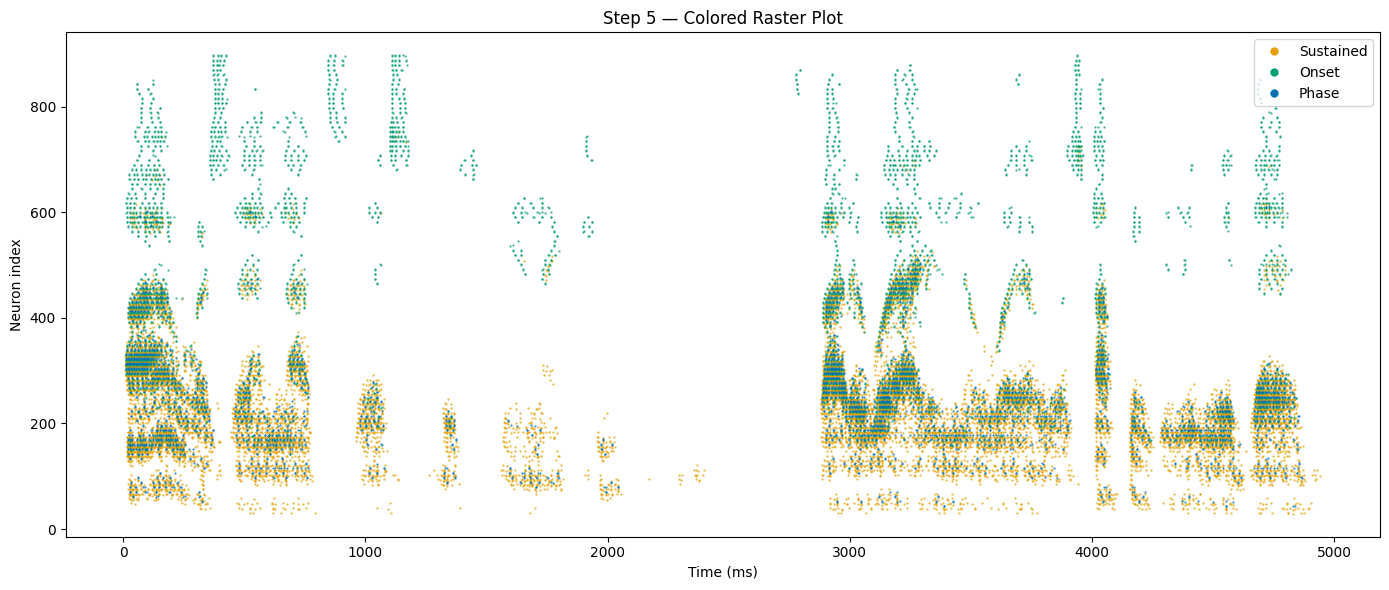

In [12]:
# ==============================
# VISUALIZATION — Colored Raster Plot
# ==============================
from matplotlib.lines import Line2D

# Color palette (colorblind-friendly)
COLOR_SUST  = '#E69F00'   # orange  → sustained
COLOR_ONSET = '#009E73'   # green   → onset
COLOR_PHASE = '#0072B2'   # blue    → phase

# Assign color per spike based on neuron type — avoid np.where (Brian2 overrides it)
local_idx    = spike_i % neurons_per_band
sust_end     = sustained_per_band
onset_end    = sustained_per_band + onset_per_band

spike_colors = np.empty(len(spike_i), dtype='<U10')
spike_colors[local_idx < sust_end]                              = COLOR_SUST
spike_colors[(local_idx >= sust_end) & (local_idx < onset_end)] = COLOR_ONSET
spike_colors[local_idx >= onset_end]                            = COLOR_PHASE

fig, ax = plt.subplots(figsize=(14, 6))
for color, label in [(COLOR_SUST, 'Sustained'), (COLOR_ONSET, 'Onset'), (COLOR_PHASE, 'Phase')]:
    mask = spike_colors == color
    ax.scatter(spike_t[mask], spike_i[mask], s=0.4, c=color, alpha=0.7, rasterized=True)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SUST,  markersize=7, label='Sustained'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_ONSET, markersize=7, label='Onset'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_PHASE, markersize=7, label='Phase'),
]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Neuron index")
ax.set_title("Step 5 — Colored Raster Plot")
plt.tight_layout()
plt.show()

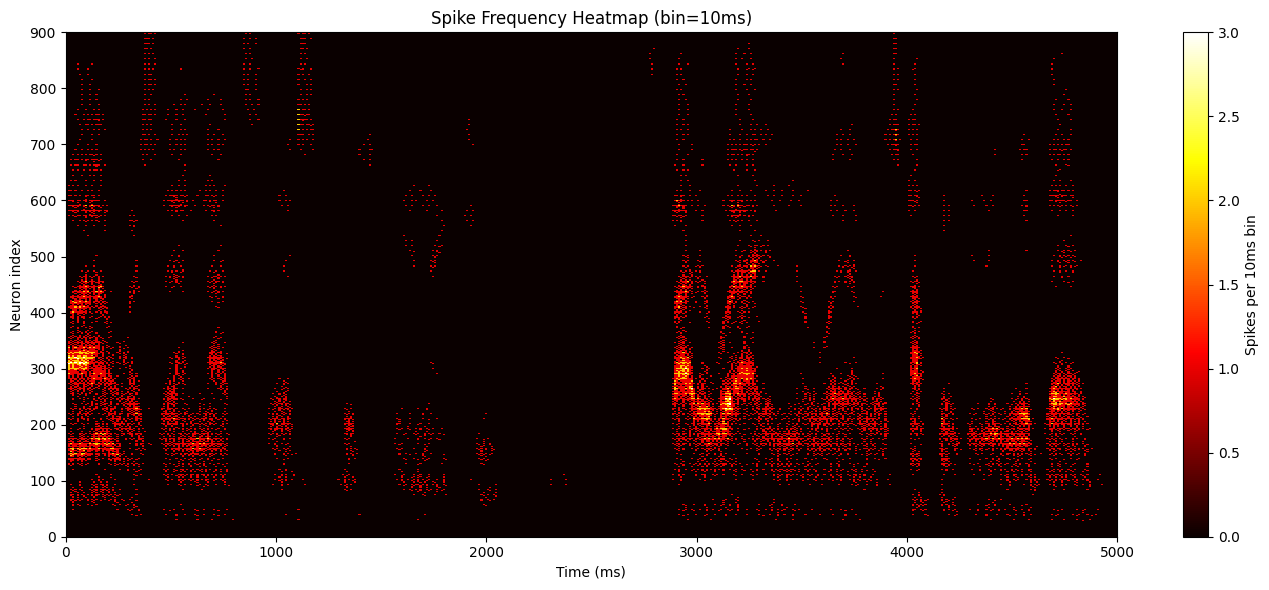

In [13]:
# ==============================
# VISUALIZATION — Spike Frequency Heatmap
# ==============================
T_ms    = T / sr * 1000
bin_ms  = 10
n_bins  = int(T_ms / bin_ms)
bin_idx = np.clip((spike_t / bin_ms).astype(int), 0, n_bins - 1)
heatmap = np.zeros((N, n_bins))
np.add.at(heatmap, (spike_i.astype(int), bin_idx), 1)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap, aspect='auto', origin='lower', cmap='hot',
               vmin=0, vmax=heatmap.max(),
               extent=[0, T_ms, 0, N], interpolation='nearest')
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Neuron index")
ax.set_title(f"Spike Frequency Heatmap (bin={bin_ms}ms)")
fig.colorbar(im, ax=ax, label=f"Spikes per {bin_ms}ms bin")
plt.tight_layout()
plt.show()

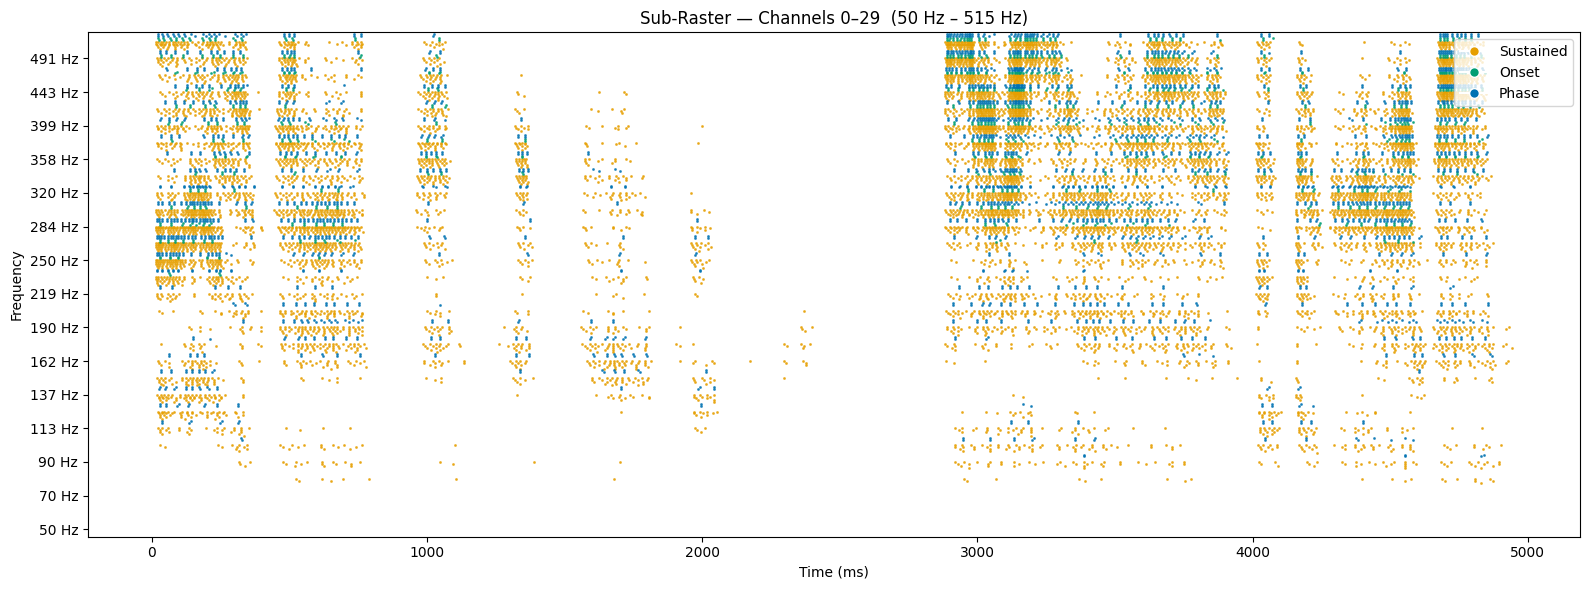

In [14]:
# ==============================
# VISUALIZATION — Sub-Raster (zoom into a band range)
# ==============================
band_start = 0   # ← tune: start channel index (0–99)
band_end   = 30  # ← tune: end channel index (exclusive)

neuron_start = band_start * neurons_per_band
neuron_end   = band_end   * neurons_per_band

mask       = (spike_i >= neuron_start) & (spike_i < neuron_end)
sub_t      = spike_t[mask]
sub_i      = spike_i[mask]
sub_colors = spike_colors[mask]

fig, ax = plt.subplots(figsize=(16, 6))
for color, label in [(COLOR_SUST, 'Sustained'), (COLOR_ONSET, 'Onset'), (COLOR_PHASE, 'Phase')]:
    m = sub_colors == color
    ax.scatter(sub_t[m], sub_i[m], s=1.2, c=color, alpha=0.7, rasterized=True)

# Y-axis ticks: show center frequency for each band in range
band_indices   = list(range(band_start, band_end))
tick_positions = [b * neurons_per_band + neurons_per_band // 2 for b in band_indices]
tick_labels    = [f"{cf[b]:.0f} Hz" for b in band_indices]
step = max(1, len(band_indices) // 12)
ax.set_yticks(tick_positions[::step])
ax.set_yticklabels(tick_labels[::step])
ax.set_ylim(neuron_start, neuron_end)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Frequency")
ax.set_title(f"Sub-Raster — Channels {band_start}–{band_end - 1}  "
             f"({cf[band_start]:.0f} Hz – {cf[band_end - 1]:.0f} Hz)")
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

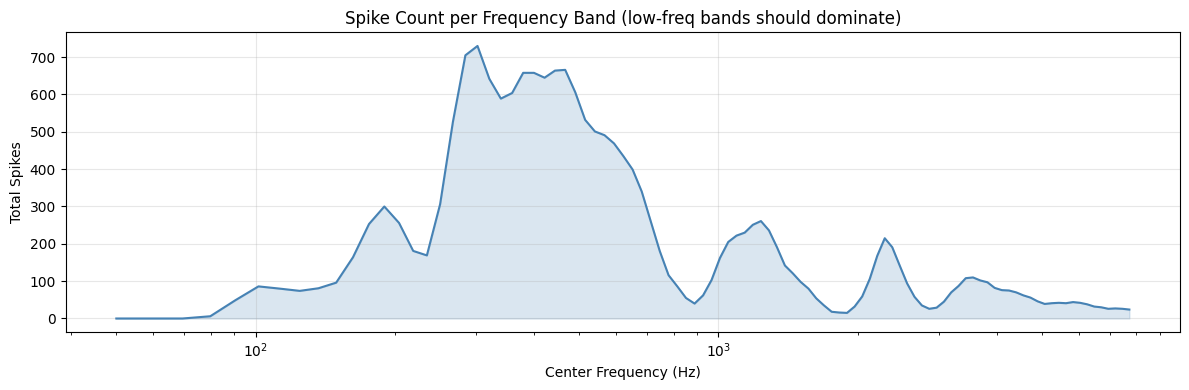

In [116]:
# ==============================
# VISUALIZATION — Spike Count per Frequency Band
# ==============================
spike_counts = np.bincount(spike_i, minlength=N)
band_totals  = spike_counts.reshape(n_channels, neurons_per_band).sum(axis=1)

plt.figure(figsize=(12, 4))
plt.plot(cf, band_totals, color='steelblue', linewidth=1.5)
plt.fill_between(cf, band_totals, alpha=0.2, color='steelblue')
plt.xlabel("Center Frequency (Hz)")
plt.ylabel("Total Spikes")
plt.xscale('log')
plt.title("Spike Count per Frequency Band (low-freq bands should dominate)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()